In [2]:
%env CUDA_VISIBLE_DEVICES = 7

env: CUDA_VISIBLE_DEVICES=7


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import cv2
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm, tqdm_notebook
import pickle

import sys
sys.path.append('..')

from visualizing import imshow, plot_predicted_mask, plot_origin_data
from train_loop import train, mIoU
from unet_model import Unet
from fetch_dataset_and_processing import find_train_val_files_adedataset, find_test_adedataset, AdeDataset, basic_transforms, augmentations_transforms

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [4]:
device = 'cuda:0'

### Load dataset 

In [5]:
train_val_images, train_val_masks = find_train_val_files_adedataset()
test_images, test_masks = find_test_adedataset()

In [6]:
train_images, val_images, train_masks, val_masks = train_test_split(train_val_images, train_val_masks, test_size=0.1)
len(train_images), len(val_images)

(18189, 2021)

In [7]:
size = 256
transforms = augmentations_transforms(size=size)

In [10]:
train_set = AdeDataset(train_images, train_masks, mode='train', transforms=transforms)
val_set = AdeDataset(val_images, val_masks, mode='val', transforms=transforms)
test_set = AdeDataset(test_images, test_masks, mode='test')

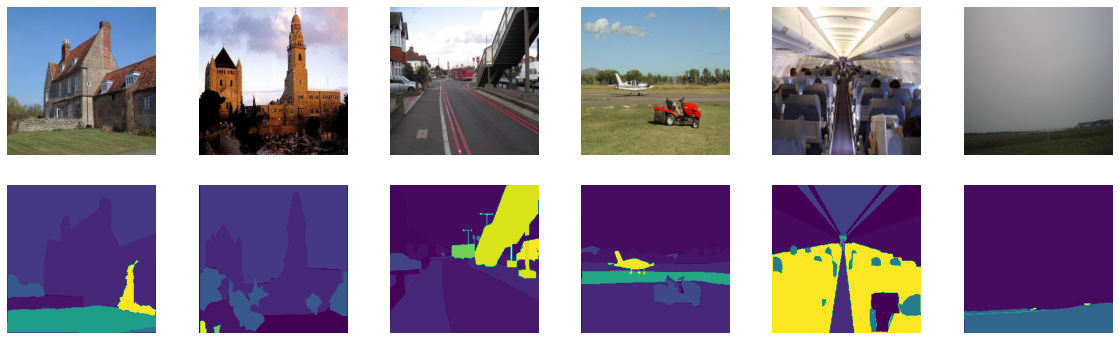

In [8]:
plot_origin_data(test_set)

### Create dataloader

In [9]:
batch_size = 8 
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True) # add GPU 
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=True)

In [10]:
test_batch_size = 32
test_loader = DataLoader(test_set, batch_size=test_batch_size, shuffle=False)

### Train model

In [11]:
unet = Unet().to(device)

In [12]:
epochs = 30
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(unet.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.1)
path = 'Unet_test.pth'
name = 'Unet_test'

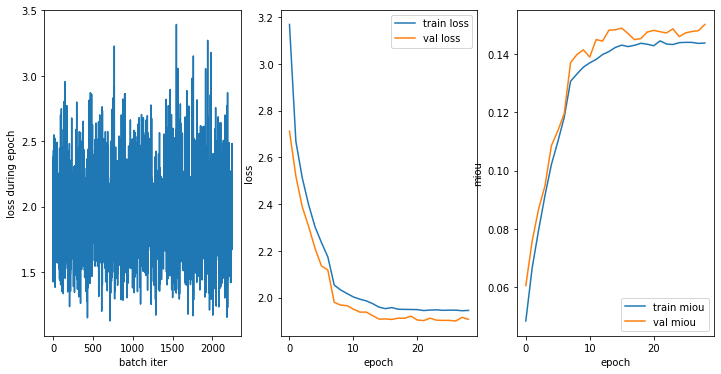

train iter:: 2274it [10:33,  3.59it/s]
val iter:: 253it [00:32,  7.88it/s]


In [20]:
losses, metrics = train(unet,
                        opt,
                        loss_fn,
                        lr_scheduler,
                        epochs,
                        train_loader,
                        val_loader,
                        name,
                        path,
                        task='segmentation',
                        segmentation_metrics=mIoU,
                        device=device
                       )

### Plot results

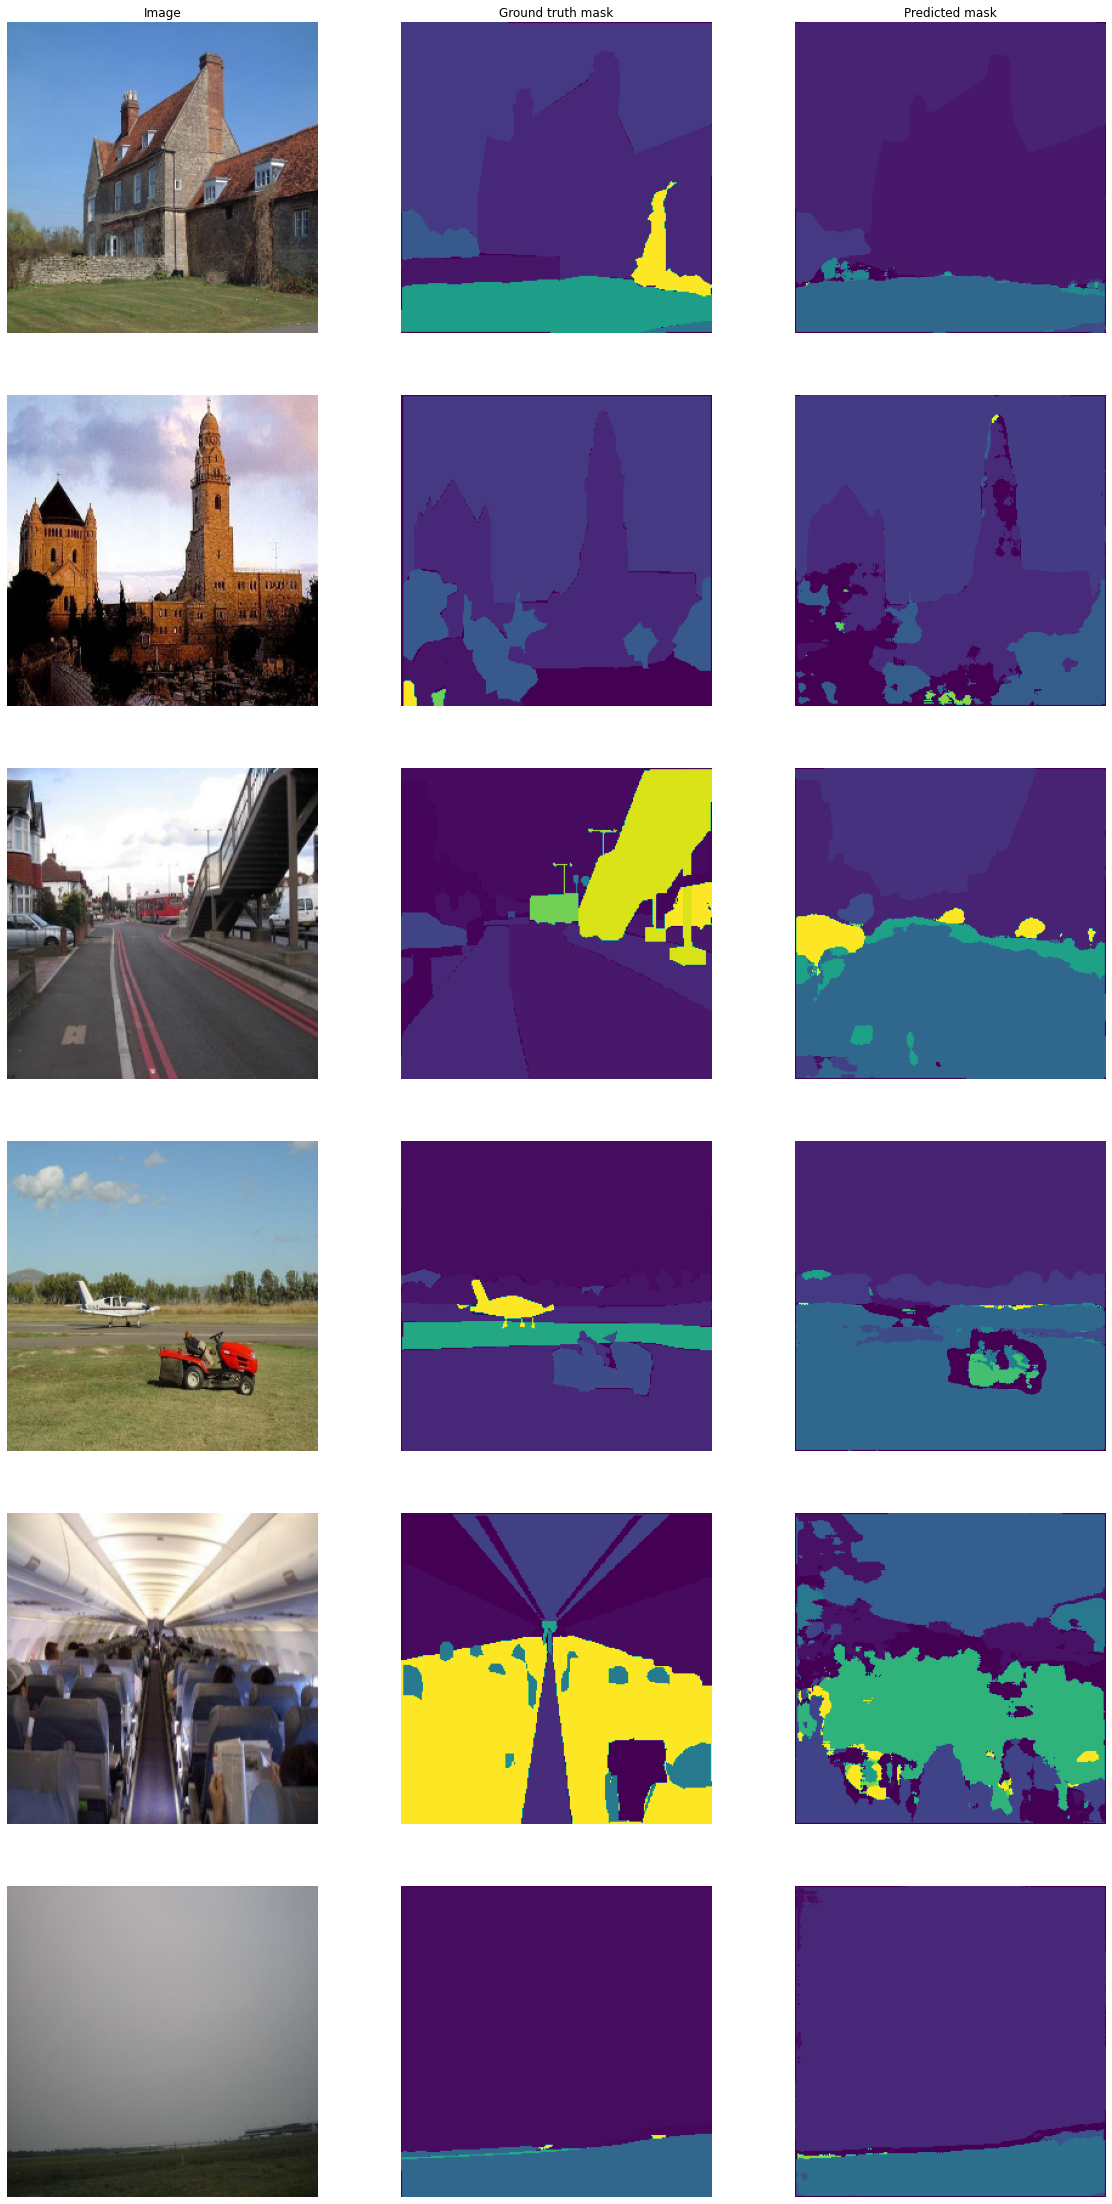

In [129]:
plot_predicted_mask(test_loader, unet, num_images=6, height=40)